In [1]:
import os
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pymc as pm
from scipy.special import erf
import pytensor.tensor as pt

filepath = '/Users/braden/Documents/Bismuth Cathode/2026-03 Zn-Kr Campaign/Krypton 10 sccm/Probe Data/RPA'

os.chdir(filepath)
os.getcwd()

'/Users/braden/Documents/Bismuth Cathode/2026-03 Zn-Kr Campaign/Krypton 10 sccm/Probe Data/RPA'

## 1. Parse the directory and extract metadata from filenames

In [2]:
def extract_metadata(f):
    parts = f.split('_')
    prop = parts[0]
    sccm = float(parts[1].split('sccm')[0])
    if 'p' in parts[2]: 
        current = float(parts[2].split('p')[0]) + float(parts[2].split('p')[1][:-1])
    else: 
        current = float(parts[2].split('A')[0])
    # Extract the type of probe
    probe = parts[3].split('.csv')[0]
    if 'RPA' in probe: probe = 'RPA'
    elif 'LP' in probe: probe = 'Langmuir'
    else: raise ValueError('Unrecognized probe type in file name ' + f)
    # Return the metadata
    return [f, prop, sccm, current, probe]

def parse_directory(path=None, savelog=True):
    # --- Navigate to the target directory ---
    if path: os.chdir(path)
    print("Parsing '" + os.getcwd() + "'")
    # -- Create the results directory if it doesn't already exist ---
    savedir = os.path.join(os.getcwd(), 'Results')
    os.makedirs(savedir, exist_ok=True)
    # --- Parse any csv file in the target directory ---
    csvs = [f for f in os.listdir() if '.csv' in f]
    metadata_table = []
    for file in csvs:
        metadata_table.append(extract_metadata(file))
    print('Parsed %i files.' % len(csvs))
    # --- Package the metadata into a pandas dataframe ---
    cols = ['Filename', 'Propellant', 'Flow [sccm]', 'Discharge Current [A]', 'Probe']
    df = pd.DataFrame(metadata_table, columns=cols)
    # --- Save the metadata to the results directory ---
    if savelog:
        df.to_csv(os.path.join(savedir, 'File Metadata.csv'), index=False)
        print("Saved metadata table to '/Results/File Metadata.csv'")
    return df
        
df = parse_directory()


Parsing '/Users/braden/Documents/Bismuth Cathode/2026-03 Zn-Kr Campaign/Krypton 10 sccm/Probe Data/RPA'
Parsed 51 files.
Saved metadata table to '/Results/File Metadata.csv'


## 2. Process the RPA traces

In [3]:
def MAD_outlier_filter(V_raw, I_raw, window=21):
    # Note: Window must be an odd number.
    halfwin = window // 2

    def clean(arr):
        outlier_indices = []
        for i in range(len(arr)):
            start = max(0, i - halfwin)
            end = min(len(arr), i + halfwin + 1)
            local_window = arr[start:end]
            local_median = np.median(local_window)
            local_mad = np.median(np.abs(local_window - local_median))
            if local_mad == 0:
                continue
            if np.abs(arr[i] - local_median) > 5 * local_mad:
                outlier_indices.append(i)
        outlier_indices = np.array(outlier_indices)
        # Return the keep_indicies array
        return np.setdiff1d(np.arange(len(arr)), outlier_indices)
    
    # --- Clean the data over the y-axis data ---
    keep_indices = clean(I_raw)
    V_clean = V_raw[keep_indices]
    I_clean = I_raw[keep_indices]
    # --- Clean the data over the x-axis data ---
    keep_indices = clean(V_clean)
    V_clean = V_clean[keep_indices]
    I_clean = I_clean[keep_indices]
    # --- Remove *duplicate* voltages (keeping the first instance) ---
    _, unique_indices = np.unique(V_clean, return_index=True)
    V = V_clean[sorted(unique_indices)]
    I = I_clean[sorted(unique_indices)]
    return V, I

def fit_dual_erf(x, y, savepath=None, bias=None, max_x=None):
    # --- 1. Cut out data above a max threshold ---
    if max_x:
        mask = x < max_x
        x = x[mask]
        y = y[mask]
    # --- 2. Normalize the data ---
    y_min = np.min(y)
    y_max = np.max(y)
    y_norm = (y - y_min) / (y_max - y_min)

    # --- 3. Define the double error function we'll fit to the data ---
    def double_error_func_tensor(x, A1, x01, sigma1, A2, x02, sigma2, C):
        term1 = A1/2 * (1 - pt.erf((x - x01)/(np.sqrt(2)*sigma1)))
        term2 = A2/2 * (1 - pt.erf((x - x02)/(np.sqrt(2)*sigma2)))
        return term1 + term2 + C

    def double_error_func(x, A1, x01, sigma1, A2, x02, sigma2, C):
        term1 = A1/2 * (1 - erf((x - x01)/(np.sqrt(2)*sigma1)))
        term2 = A2/2 * (1 - erf((x - x02)/(np.sqrt(2)*sigma2)))
        return term1 + term2 + C

    # --- 4. Set up the priors ---
    with pm.Model() as model:
        # Low energy priors
        A1 = pm.HalfNormal("A1", sigma=1)
        x01 = pm.Uniform("x01", lower=min(x), upper=50)
        sigma1 = pm.HalfNormal("sigma1", sigma=20)
        # High energy priors
        A2 = pm.HalfNormal("A2", sigma=1)
        if bias is not None:  x02 = pm.Uniform("x02", lower=30, upper=float(bias)) # Center cannot be higher than bias
        else: x02 = pm.Uniform("x02", lower=30, upper=max(x))   # If bias is not given, search the whole range
        #x02 = pm.Uniform("x02", lower=30, upper=biasfloat)
        sigma2 = pm.HalfNormal("sigma2", sigma=20)
        # Vertical offset parameter
        C = pm.Normal("C", mu=0, sigma=0.1)
        
        mu = double_error_func_tensor(x, A1, x01, sigma1, A2, x02, sigma2, C)
        
        sigma_noise = pm.HalfNormal("sigma_noise", sigma=0.05)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_noise, observed=y_norm)
        
        # --- 5. Run the MCMC ---
        #print(model.initial_point())
        trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)

    # --- 6. Unscale the model ---
    # Use median or mean posterior values for prediction
    A1_m = trace.posterior['A1'].mean().item()
    x01_m = trace.posterior['x01'].mean().item()
    sigma1_m = trace.posterior['sigma1'].mean().item()
    A2_m = trace.posterior['A2'].mean().item()
    x02_m = trace.posterior['x02'].mean().item()
    sigma2_m = trace.posterior['sigma2'].mean().item()
    C_m = trace.posterior['C'].mean().item()
    # Model in normalized space:
    model_fit_norm = double_error_func(x, A1_m, x01_m, sigma1_m, A2_m, x02_m, sigma2_m, C_m)
    # Unscale to original units:
    model_fit = model_fit_norm * (y_max - y_min) + y_min

    # --- 7. Plot for comparison ---
    if savepath is not None:
        plt.figure()
        plt.plot(x, y, 'b.', label='Raw Data')
        plt.plot(x, model_fit, label='Posterior Fit', linewidth=1)
        plt.xlabel('Voltage [V]')
        plt.ylabel('Current Current [A]')
        plt.legend()
        plt.savefig(savepath, dpi=300)
        plt.close()

    # --- 8. Do statistics and retrieve current values ---
    x01_samples = trace.posterior["x01"].values.flatten()
    x01_l, x01_u = np.percentile(x01_samples,[2.5,97.5])    # Compute 95% confidence interval bounds

    x01_m_cur = y[np.abs(x - x01_m).argmin()]    # Mean current
    x01_l_cur = y[np.abs(x - x01_u).argmin()]    # Lower current bound (from upper MPV)
    x01_u_cur = y[np.abs(x - x01_l).argmin()]    # Upper current bound (from lower MPV)

    x02_samples = trace.posterior["x02"].values.flatten()
    x02_l, x02_u = np.percentile(x02_samples,[2.5,97.5])    # Compute 95% confidence interval bounds

    #x02_m_cur = y[np.abs(x - x02_m).argmin()]    # Mean current
    idx = np.abs(x - x02_m).argmin()    # Index of mean current
    x02_m_cur = np.mean(y[idx-5:idx+5])
    #x02_l_cur = y[np.abs(x - x02_u).argmin()]    # Lower current bound (from upper MPV)
    idx = np.abs(x - x02_u).argmin()    # Index of mean current
    x02_l_cur = np.mean(y[idx-5:idx+5])
    #x02_u_cur = y[np.abs(x - x02_l).argmin()]    # Upper current bound (from lower MPV)
    idx = np.abs(x - x02_l).argmin()    # Index of mean current
    x02_u_cur = np.mean(y[idx-5:idx+5])

    print(f"V01 (low energy center): mean={x01_m:.2f} V, 95% CI=({x01_l}, {x01_u})")
    print(f"V02 (high energy center): mean={x02_m:.2f} V, 95% CI=({x02_l}, {x02_u})")

    return [x01_m, x01_l, x01_u, x01_m_cur, x01_l_cur, x01_u_cur, 
            x02_m, x02_l, x02_u, x02_m_cur, x02_l_cur, x02_u_cur]

def fit_erf(x, y, savepath=None, max_x=None):
    # --- 1. Cut out data above a max threshold ---
    if max_x:
        mask = x < max_x
        x = x[mask]
        y = y[mask]
    # --- 2. Normalize the data ---
    y_min = np.min(y)
    y_max = np.max(y)
    y_norm = (y - y_min) / (y_max - y_min)

    # --- 3. Define the single error function we'll fit to the data ---
    def single_error_func_tensor(x, A, x0, sigma, C):
        return A/2 * (1 - pt.erf((x - x0)/(np.sqrt(2)*sigma))) + C

    def single_error_func(x, A, x0, sigma, C):
        return A/2 * (1 - erf((x - x0)/(np.sqrt(2)*sigma))) + C

    # --- 4. Set up the priors ---
    with pm.Model() as model:
        # Gaussian Priors
        A = pm.HalfNormal("A", sigma=1)
        x0 = pm.Uniform("x0", lower=min(x), upper=max(x))
        sigma = pm.HalfNormal("sigma", sigma=20)
        # Vertical offset parameter
        C = pm.Normal("C", mu=0, sigma=0.1)
        
        mu = single_error_func_tensor(x, A, x0, sigma, C)
        
        sigma_noise = pm.HalfNormal("sigma_noise", sigma=0.05)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_noise, observed=y_norm)
        
        # --- 5. Run the MCMC ---
        trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)

    # --- 6. Unscale the model & Compute Credible Interval ---
    
    # Extract flattened posterior samples for all parameters
    A_samples = trace.posterior['A'].values.flatten()
    x0_samples = trace.posterior['x0'].values.flatten()
    sigma_samples = trace.posterior['sigma'].values.flatten()
    C_samples = trace.posterior['C'].values.flatten()

    # Calculate the mean prediction (what you originally had)
    A_m, x0_m, sigma_m, C_m = A_samples.mean(), x0_samples.mean(), sigma_samples.mean(), C_samples.mean()
    model_fit_norm_mean = single_error_func(x, A_m, x0_m, sigma_m, C_m)
    model_fit_mean = model_fit_norm_mean * (y_max - y_min) + y_min

    # Calculate predictions across the entire posterior distribution
    # We use np.newaxis to broadcast shapes: x becomes (N, 1) and samples become (1, M)
    # The output will be a 2D array of shape (N_data_points, N_samples)
    X_grid = x[:, np.newaxis]
    all_fits_norm = single_error_func(
        X_grid, 
        A_samples[np.newaxis, :], 
        x0_samples[np.newaxis, :], 
        sigma_samples[np.newaxis, :], 
        C_samples[np.newaxis, :]
    )
    
    # Unscale all the fitted curves to original units
    all_fits = all_fits_norm * (y_max - y_min) + y_min

    # Calculate the 2.5% and 97.5% percentiles at each x data point (95% Credible Interval)
    fit_lower = np.percentile(all_fits, 2.5, axis=1)
    fit_upper = np.percentile(all_fits, 97.5, axis=1)

    # --- 7. Plot for comparison ---
    if savepath is not None:
        plt.figure()
        plt.plot(x, y, 'b.', label='Raw Data', markersize=4)
        
        # Plot the 95% Credible Interval band
        plt.fill_between(x, fit_lower, fit_upper, color='orange', alpha=0.4, label='95% Credible Interval')
        
        # Plot the mean fit on top
        plt.plot(x, model_fit_mean, 'k-', label='Mean Posterior Fit')
        
        plt.xlabel('Voltage [V]')
        plt.ylabel('Current [A]') # (Note: Fixed a small 'Current Current' typo here)
        plt.legend()
        plt.savefig(savepath, dpi=300)
        plt.close()

    # --- 8. Do statistics and retrieve current values ---
    x0_samples = trace.posterior["x0"].values.flatten()
    x0_l, x0_u = np.percentile(x0_samples,[2.5,97.5])    # Compute 95% confidence interval bounds

    x0_m_cur = y[np.abs(x - x0_m).argmin()]    # Mean current
    x0_l_cur = y[np.abs(x - x0_u).argmin()]   # Lower current bound (from upper MPV)
    x0_u_cur = y[np.abs(x - x0_l).argmin()]   # Upper current bound (from lower MPV)

    print(f"V0 (low energy center): mean={x0_m:.2f} V, 95% CI=({x0_l}, {x0_u})")

    # Rescale the y-axis fit parameters prior to returning
    fit_params = [A_m * (y_max - y_min) + y_min, 
                  x0_m, sigma_m, 
                  C_m * (y_max - y_min) + y_min]
    return [x0_m, x0_l, x0_u, fit_params]

# --- PROCESS THE CURRENT WORKING DIRECTORY ---

savedir = os.path.join(os.getcwd(), 'Results')
try:    # Create the results database if it doesn't already exist
    out = pd.read_csv(os.path.join(savedir, 'RPA Results.csv'))
except: # Otherwise create an empty database
    out = pd.DataFrame(columns=['Filename', 'Mean MPV [V]', 'Lower 95% CI [V]', 
                    'Upper 95% CI [V]', 'Fit Parameters [A, x0, sigma, C]'])
    out.to_csv(os.path.join(savedir, 'RPA Results.csv'), index=False)

for _, row in df.iterrows():
    if row['Probe'] == 'RPA': 
        out = pd.read_csv(os.path.join(savedir, 'RPA Results.csv'))
        if row['Filename'] not in out['Filename'].values:
            print('Processing ' + row['Filename'])
            # -- Unpack the data --
            RPA_df = pd.read_csv(row['Filename'], delimiter='\t')
            V = RPA_df['Bias Voltage (V)'].to_numpy()
            I = RPA_df['Probe Current (A)'].to_numpy()
            # -- Filter outliers --
            x, y = MAD_outlier_filter(V, I)
            # -- Perform the bayesian fit and save an output image
            savepath = savedir + '/' + row['Filename'][:-4] + '.png'
            params = fit_erf(x, y, savepath)
            # -- Add these results as a row to the output dataframe
            out.loc[len(out)] = [row['Filename'], *params]
            out.to_csv(os.path.join(savedir, 'RPA Results.csv'), index=False)
        else:
            print('Already processed ' + row['Filename'])

Already processed Kr_10sccm_23A_RPA.csv
Already processed Kr_10sccm_22A_RPA.csv
Already processed Kr_10sccm_17A_RPA.csv
Already processed Kr_10sccm_16A_RPA.csv
Already processed Kr_10sccm_15A_RPA2.csv
Already processed Kr_10sccm_20A_RPA2.csv
Already processed Kr_10sccm_24A_RPA.csv
Already processed Kr_10sccm_25A_RPA.csv
Already processed Kr_10sccm_10A_RPA.csv
Already processed Kr_10sccm_11A_RPA.csv
Already processed Kr_10sccm_23A_RPA2.csv
Already processed Kr_10sccm_17p5A_RPA.csv
Already processed Kr_10sccm_10A_RPA2.csv
Already processed Kr_10sccm_12p5A_RPA.csv
Already processed Kr_10sccm_14A_RPA.csv
Already processed Kr_10sccm_15A_RPA.csv
Already processed Kr_10sccm_25A_RPA2.csv
Already processed Kr_10sccm_20A_RPA.csv
Processing Kr_10sccm_21A_RPA.csv


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, x0, sigma, C, sigma_noise]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


V0 (low energy center): mean=62.79 V, 95% CI=(62.29160458169739, 63.30038609568059)
Processing Kr_10sccm_13A_RPA.csv


...

V0 (low energy center): mean=69.78 V, 95% CI=(66.25110130873487, 73.32301903198885)
Processing Kr_10sccm_30A_RPA.csv


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, x0, sigma, C, sigma_noise]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


V0 (low energy center): mean=122.26 V, 95% CI=(3.96273516008146, 159.98927821983628)


## 3. Plot the results

In [17]:
resultspath = '/Users/braden/Documents/Bismuth Cathode/2026-03 Zn-Kr Campaign/Krypton 10 sccm/Probe Data/RPA/Results'

os.chdir(resultspath)
metadata = pd.read_csv('File Metadata.csv')
results = pd.read_csv('RPA Results.csv')
metadata_RPA = metadata[metadata['Probe'] == 'RPA']

master = pd.merge(metadata_RPA, results, on='Filename')
master.head()

,Filename,Propellant,Flow [sccm],Discharge Current [A],Probe,Mean MPV [V],Lower 95% CI [V],Upper 95% CI [V],"Fit Parameters [A, x0, sigma, C]"
0,Kr_10sccm_23A_RPA.csv,Kr,10.0,23.0,RPA,54.688813,53.515734,55.898382,"[4.7447373382849606e-08, 54.68881272214497, 7...."
1,Kr_10sccm_23A_RPA.csv,Kr,10.0,23.0,RPA,54.688422,53.567310,55.856972,"[4.744514883798434e-08, 54.688421639136585, 7...."
2,Kr_10sccm_22A_RPA.csv,Kr,10.0,22.0,RPA,58.260957,57.772418,58.745108,"[3.7546225766949377e-07, 58.26095720599709, 16..."
3,Kr_10sccm_22A_RPA.csv,Kr,10.0,22.0,RPA,58.247565,57.758514,58.740098,"[3.7546038515498905e-07, 58.247564887913384, 1..."
4,Kr_10sccm_17A_RPA.csv,Kr,10.0,17.0,RPA,81.168888,80.362378,81.970764,"[4.306928328200716e-07, 81.16888774101986, 14...."


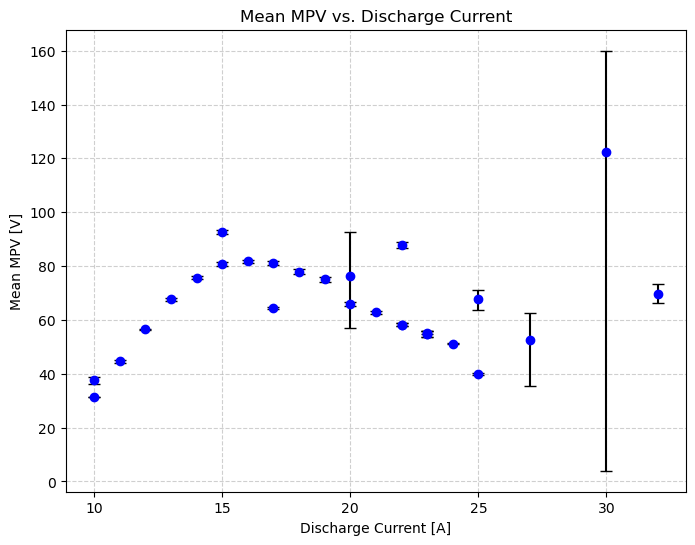

In [18]:
# 1. Calculate the relative error distances
yerr_lower = master['Mean MPV [V]'] - master['Lower 95% CI [V]']
yerr_upper = master['Upper 95% CI [V]'] - master['Mean MPV [V]']

# Combine into a 2D array for Matplotlib
asymmetric_error = [yerr_lower, yerr_upper]

# 2. Create the plot
plt.figure(figsize=(8, 6))

plt.errorbar(
    x=master['Discharge Current [A]'], 
    y=master['Mean MPV [V]'], 
    yerr=asymmetric_error,
    fmt='o',           # 'o' makes it a scatter plot with dots
    capsize=4,         # Adds little horizontal caps to the error bars
    color='blue', 
    ecolor='black',    # Color of the error bars
    linestyle='none'   # Ensures lines don't connect the scatter points
)

# 3. Format the axes
plt.xlabel('Discharge Current [A]')
plt.ylabel('Mean MPV [V]')
plt.title('Mean MPV vs. Discharge Current')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()